In [4]:
import sys
import os
sys.path.append(os.path.abspath(".."))


import json
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torchvision.transforms.functional as TF
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt


from src.dataset.bbbc038 import BBBC038Dataset, SegmentationTransform
from src.nn.models import UNet, train_loop, test_loop
from src.nn.optimizers import create_optimizer
from src.plot.plot import plot_resultados
from src.nn.metrics import *

In [14]:
# Definindo a seed e o device (GPU se disponível, caso contrário CPU)
SEED = 67
SIZE = (128, 128)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Definindo o dataset, dataloaders, modelo, função de perda e otimizador
transform = SegmentationTransform(
    size=SIZE,
    augment=True
)
dataset = BBBC038Dataset(
    root="../data/stage1_train",
    transform=transform,
    mode="semantic"
)

# Mesmo dataset, mas SEM augmentation, para avaliação.
#
# A extração de instâncias compara a predição com as máscaras
# individuais lidas do disco, que não passam pelo transform. Se a
# imagem de validação for espelhada pelo augment, a predição fica
# desalinhada do ground truth e o IoU vai a zero por construção.
eval_transform = SegmentationTransform(
    size=SIZE,
    augment=False
)
eval_dataset = BBBC038Dataset(
    root="../data/stage1_train",
    transform=eval_transform,
    mode="semantic"
)

train_len = int(0.8 * len(dataset))
val_len = len(dataset) - train_len

# O mesmo generator nas duas chamadas garante os MESMOS índices,
# então o split é idêntico ao usado na Parte 2.
train_dataset, _ = random_split(
    dataset,
    [train_len, val_len],
    generator=torch.Generator().manual_seed(SEED)
)
_, val_dataset = random_split(
    eval_dataset,
    [train_len, val_len],
    generator=torch.Generator().manual_seed(SEED)
)

batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)
eval_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

model = UNet(num_classes=2).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = create_optimizer("Adam",model,lr=1e-3)

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

Epoch 1/10 | Train Loss: 0.6135 | Val Loss: 0.6590 | Pixel Accuracy: 0.8267
Epoch 2/10 | Train Loss: 0.4713 | Val Loss: 0.9241 | Pixel Accuracy: 0.4609
Epoch 3/10 | Train Loss: 0.4054 | Val Loss: 0.9002 | Pixel Accuracy: 0.4304
Epoch 4/10 | Train Loss: 0.3549 | Val Loss: 0.3260 | Pixel Accuracy: 0.9676
Epoch 5/10 | Train Loss: 0.3111 | Val Loss: 0.2545 | Pixel Accuracy: 0.9687
Epoch 6/10 | Train Loss: 0.2731 | Val Loss: 0.2380 | Pixel Accuracy: 0.9713
Epoch 7/10 | Train Loss: 0.2364 | Val Loss: 0.2215 | Pixel Accuracy: 0.9683
Epoch 8/10 | Train Loss: 0.1999 | Val Loss: 0.1886 | Pixel Accuracy: 0.9674
Epoch 9/10 | Train Loss: 0.1760 | Val Loss: 0.1578 | Pixel Accuracy: 0.9705
Epoch 10/10 | Train Loss: 0.1577 | Val Loss: 0.2074 | Pixel Accuracy: 0.9451


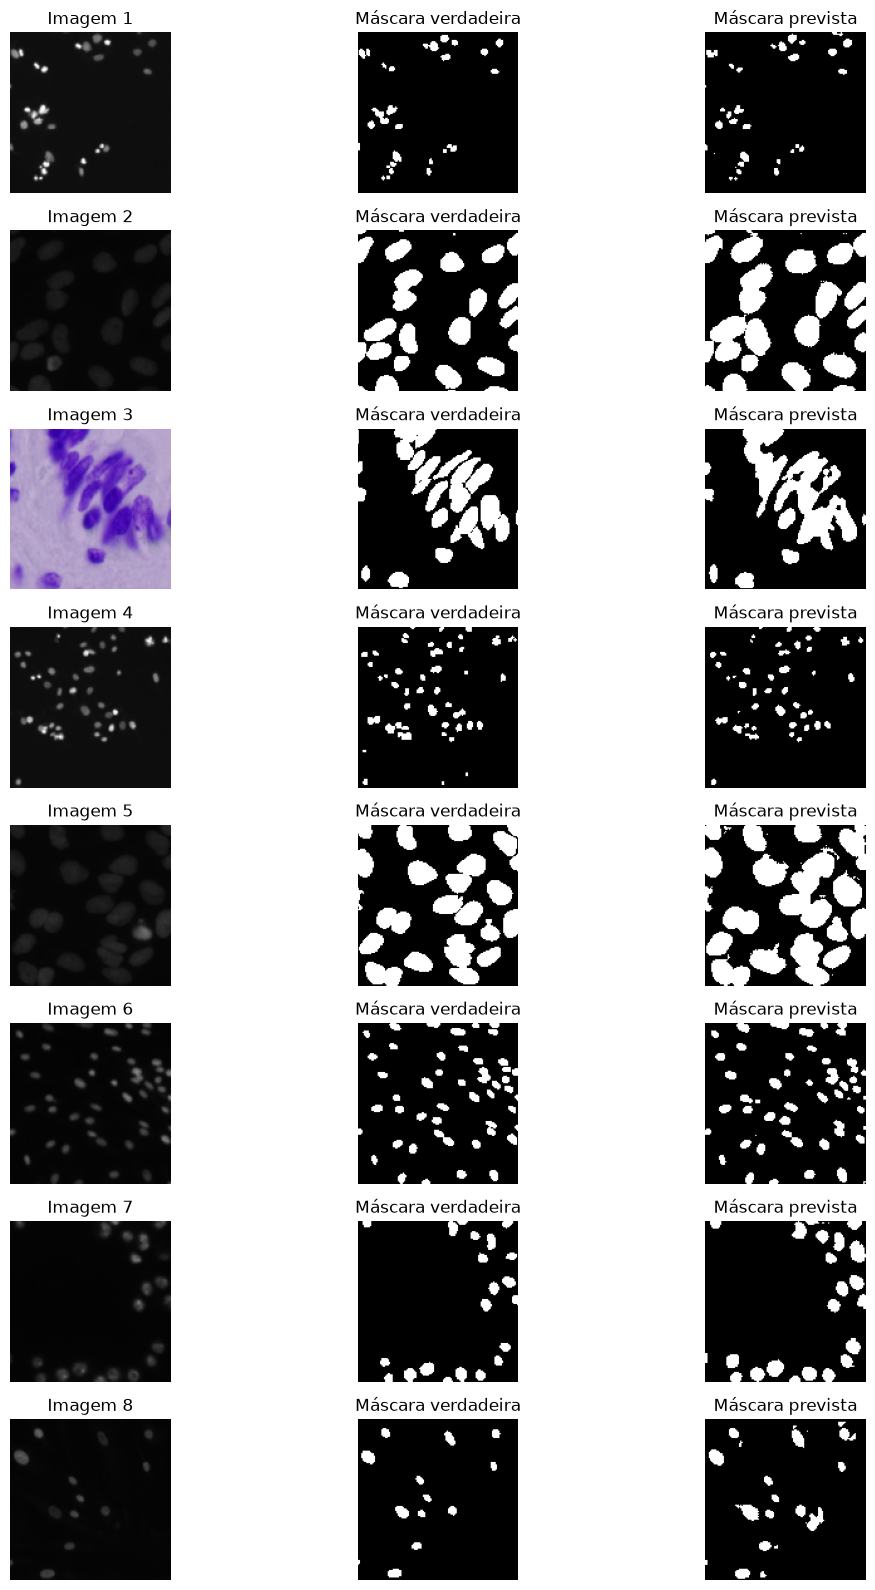

In [6]:
# Treinamento e validação do modelo
NUM_EPOCHS = 10
for epoch in range(NUM_EPOCHS):
    train_loss = train_loop(train_loader, device, model, loss_fn, optimizer)
    val_loss, pixel_acc = test_loop(val_loader, device, model, loss_fn)
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Pixel Accuracy: {pixel_acc:.4f}"
    )
plot_resultados(model, val_loader, device, num_images=8)

In [7]:
# ============================================================
# EXTRAÇÃO INGÊNUA DE INSTÂNCIAS  --  limiar + componentes conexos
# ============================================================
#
# Este é o método da Parte 1: a rede só prevê fundo vs. objeto, e as
# instâncias saem de scipy.ndimage.label sobre a máscara binária.
# Núcleos encostados viram UM componente -- é justamente esse fracasso
# que a Parte 2 vai atacar.
# ============================================================

@torch.no_grad()
def evaluate_instances(model, dataloader, dataset, device, threshold=0.5):
    """
    Avalia o baseline semântico como segmentação de instâncias.

    Returns:
        predictions:   lista (por imagem) de listas de máscaras previstas
        ground_truths: lista (por imagem) de listas de máscaras verdadeiras
        scores:        lista (por imagem) de listas de confianças
        count_errors:  lista de dicts {true, pred, error}
        semantic:      {"iou": ..., "dice": ...} médios (fundo vs. objeto)
    """

    model.eval()

    predictions = []
    ground_truths = []
    scores = []
    count_errors = []
    semantic_iou = []
    semantic_dice = []

    # Índices originais das imagens dentro do Subset
    subset_indices = dataloader.dataset.indices
    position = 0

    for X, _ in dataloader:

        X = X.to(device)

        outputs = model(X)

        # Probabilidade da classe "objeto"
        foreground_probability = (
            torch.softmax(outputs, dim=1)[:, 1]
            .cpu()
            .numpy()
        )

        for i in range(X.shape[0]):

            foreground_mask = foreground_probability[i] > threshold
            size = foreground_mask.shape

            # ---------------------------------------------------
            # GROUND TRUTH  (máscaras individuais, redimensionadas)
            # ---------------------------------------------------

            sample = dataset.samples[int(subset_indices[position])]
            position += 1

            gt_instances = []
            gt_union = np.zeros(size, dtype=bool)

            for gt in dataset._load_instance_masks(sample["masks"]):

                gt_image = Image.fromarray(
                    (gt.astype(np.uint8) * 255)
                )

                gt_image = TF.resize(
                    gt_image,
                    size,
                    interpolation=TF.InterpolationMode.NEAREST
                )

                gt_array = np.array(gt_image) > 0

                gt_instances.append(gt_array)
                gt_union |= gt_array

            # ---------------------------------------------------
            # MÉTRICAS SEMÂNTICAS  (Parte 1, item 1)
            # ---------------------------------------------------

            iou, dice_value = binary_iou_dice(foreground_mask, gt_union)

            semantic_iou.append(iou)
            semantic_dice.append(dice_value)

            # ---------------------------------------------------
            # INSTÂNCIAS: limiar + componentes conexos
            # ---------------------------------------------------

            pred_instances = connected_components(foreground_mask)

            pred_scores = instance_scores(
                foreground_probability[i],
                pred_instances
            )

            # ---------------------------------------------------
            # SALVA
            # ---------------------------------------------------

            predictions.append(pred_instances)
            ground_truths.append(gt_instances)
            scores.append(pred_scores)

            count_errors.append({
                "true": len(gt_instances),
                "pred": len(pred_instances),
                "error": abs(len(pred_instances) - len(gt_instances))
            })

    semantic = {
        "iou": float(np.mean(semantic_iou)),
        "dice": float(np.mean(semantic_dice))
    }

    return predictions, ground_truths, scores, count_errors, semantic

In [8]:
predictions, ground_truths, scores, count_errors, semantic = evaluate_instances(
    model,
    eval_loader,
    eval_dataset,
    device,
    threshold=0.5
)

print("Métricas semânticas (fundo vs. objeto):")
print(f"  IoU  = {semantic['iou']:.4f}")
print(f"  Dice = {semantic['dice']:.4f}")

map_value, aps = mean_average_precision(
    predictions,
    ground_truths,
    scores
)

print("\nAP por IoU:")

for threshold, ap in aps.items():
    print(
        f"AP@{threshold:.2f}: {ap:.4f}"
    )

print(
    f"\nmAP@50:95 = {map_value:.4f}"
)

Métricas semânticas (fundo vs. objeto):
  IoU  = 0.6517
  Dice = 0.7714

AP por IoU:
AP@0.50: 0.3731
AP@0.55: 0.3336
AP@0.60: 0.2981
AP@0.65: 0.2566
AP@0.70: 0.1971
AP@0.75: 0.1259
AP@0.80: 0.0567
AP@0.85: 0.0156
AP@0.90: 0.0020
AP@0.95: 0.0001

mAP@50:95 = 0.1659


In [9]:
# Regra de matching: guloso por IoU decrescente
# (src/nn/metrics.py::match_instances). Cada predição casa com no
# máximo um ground truth, e cada ground truth com no máximo uma predição.

for threshold in np.arange(
    0.50,
    0.951,
    0.05
):

    tp, fp, fn = count_tp_fp_fn(
        predictions,
        ground_truths,
        threshold
    )

    print(
        f"IoU={threshold:.2f} | "
        f"TP={tp} | "
        f"FP={fp} | "
        f"FN={fn}"
    )

IoU=0.50 | TP=2783 | FP=1434 | FN=3347
IoU=0.55 | TP=2592 | FP=1625 | FN=3538
IoU=0.60 | TP=2403 | FP=1814 | FN=3727
IoU=0.65 | TP=2184 | FP=2033 | FN=3946
IoU=0.70 | TP=1861 | FP=2356 | FN=4269
IoU=0.75 | TP=1437 | FP=2780 | FN=4693
IoU=0.80 | TP=928 | FP=3289 | FN=5202
IoU=0.85 | TP=485 | FP=3732 | FN=5645
IoU=0.90 | TP=177 | FP=4040 | FN=5953
IoU=0.95 | TP=33 | FP=4184 | FN=6097


In [10]:
df = pd.DataFrame(
    count_errors
)

print(df)

     true  pred  error
0      33    32      1
1      27    24      3
2      25     9     16
3      56    44     12
4      28    34      6
..    ...   ...    ...
129    27    24      3
130    21    19      2
131    66    52     14
132    31    23      8
133    14    14      0

[134 rows x 3 columns]


In [11]:
mean_count_error = df["error"].mean()

print(
    f"Erro médio de contagem: "
    f"{mean_count_error:.4f}"
)

Erro médio de contagem: 18.9030


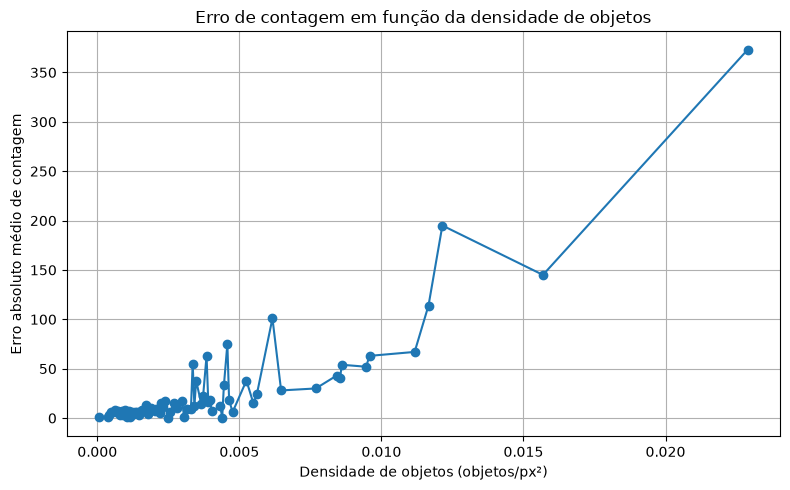

In [15]:
# Quantificando o fracasso: erro de contagem em função da densidade.
#
# Agrupamos pelo número de objetos verdadeiros na imagem, que é a
# densidade em si -- dividir por H*W só reescala o eixo e torna o
# gráfico ilegível.

# Defina a área total da imagem (ex: 1920 * 1080 ou em megapixels)
AREA_PX = SIZE[0] * SIZE[1]

# Calcula a densidade por imagem
df["density"] = df["true"] / AREA_PX

grouped = (
    df
    .groupby("density")["error"]
    .mean()
)

plt.figure(figsize=(8, 5))
plt.plot(grouped.index, grouped.values, marker="o")
plt.xlabel("Densidade de objetos (objetos/px²)")
plt.ylabel("Erro absoluto médio de contagem")
plt.title("Erro de contagem em função da densidade de objetos")
plt.grid()
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# SALVA OS NÚMEROS DA PARTE 1
# ============================================================
#
# O 2_instances.ipynb lê este arquivo para montar a coluna
# "Parte 1 (U-Net semântica)" na tabela lado a lado.
# ============================================================

tp50, fp50, fn50 = count_tp_fp_fn(predictions, ground_truths, 0.50)

baseline_metrics = {
    "IoU (semantico)":        semantic["iou"],
    "Dice (semantico)":       semantic["dice"],
    "mAP@[.50:.95]":          float(map_value),
    "AP@0.50":                float(aps[0.5]),
    "AP@0.75":                float(aps[0.75]),
    "AP@0.90":                float(aps[0.9]),
    "TP@0.50":                int(tp50),
    "FP@0.50":                int(fp50),
    "FN@0.50":                int(fn50),
    "erro medio de contagem": float(mean_count_error),
}

with open(os.path.join(RESULTS_DIR, "1_baseline.json"), "w") as fh:
    json.dump(baseline_metrics, fh, indent=2)

print(json.dumps(baseline_metrics, indent=2))

{
  "IoU (semantico)": 0.6516703520250514,
  "Dice (semantico)": 0.7714057264871891,
  "mAP@[.50:.95]": 0.1658719813460685,
  "AP@0.50": 0.37309577649765346,
  "AP@0.75": 0.12589378030638163,
  "AP@0.90": 0.0019698728281826727,
  "TP@0.50": 2783,
  "FP@0.50": 1434,
  "FN@0.50": 3347,
  "erro medio de contagem": 18.902985074626866
}
